In [1]:
# >>> ────────────────────────────────────────────────────────────────────── <<<
# >>> CELL 01: RUNTIME SETUP AND ENVIRONMENT CONTROL                         <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<

# !pip uninstall -y torch torchvision torchaudio torch-scatter
# !pip uninstall -y  torch-sparse torch-geometric

# !pip install torch==2.0.0+cu118 torchvision==0.15.1+cu118 torchaudio==2.0.1+cu118 -f https://download.pytorch.org/whl/torch_stable.html
# !pip install torch-scatter torch-sparse torch-geometric -f https://data.pyg.org/whl/torch-2.0.0+cu118.html
# !pip install numpy==1.24.4
# !pip install Optuna

# >>> END CELL 01 (ON FIRST RUN USER RESTART IS REQUIRED)                    <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<

In [2]:
# >>> ────────────────────────────────────────────────────────────────────── <<<
# >>> CELL 02: IMPORT STATEMENTS                                              <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<

# Torch and torch utilities
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import Adam
import torch_geometric
from torch_geometric.data import HeteroData
from torch_geometric.nn import SAGEConv, HeteroConv

# Sklearn encoding, training, evaluation tools
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

# Optuna parameter tuning
import optuna
from optuna.visualization import plot_optimization_history

# Numbers
import numpy as np

# Data handling
from shapely.geometry import Point
import geopandas as gpd
import pandas as pd

# Visuals
import matplotlib.pyplot as plt

# Utility
from google.colab import files
import collections
from collections import Counter
import datetime
import tabulate
from tabulate import tabulate
import inspect
import random
import math
import time
import re
import os

# Set the random seed
def jenny_setter(seed):
  torch.manual_seed(seed)
  np.random.seed(seed)
  random.seed(seed)
  optuna.logging.set_verbosity(optuna.logging.WARNING)
  if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
  torch.backends.cudnn.deterministic=True
  torch.backends.cudnn.benchmark=False

jenny = 8675309
jenny_setter(jenny)

# Output to verify runtime is correct.
rows = [
    ['Torch', '2.0.0+cu118', torch.__version__],
    ['CUDA_version','11.8',torch.version.cuda],
    ['NumPy','1.24.4',np.__version__]
]
print('Be sure that library expected and current versions match:')
print(tabulate(rows, headers=['Library', 'Expected Version', 'Current Version'], tablefmt='grid'))
print('─────────────────────────────────────────────────────────')
# >>> END CELL 02                                                            <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<

Be sure that library expected and current versions match:
+--------------+--------------------+-------------------+
| Library      | Expected Version   | Current Version   |
+==============+====================+===================+
| Torch        | 2.0.0+cu118        | 2.0.0+cu118       |
+--------------+--------------------+-------------------+
| CUDA_version | 11.8               | 11.8              |
+--------------+--------------------+-------------------+
| NumPy        | 1.24.4             | 1.24.4            |
+--------------+--------------------+-------------------+
─────────────────────────────────────────────────────────


In [3]:
# >>> ────────────────────────────────────────────────────────────────────── <<<
# >>> CELL 3: UTILITY VARIABLES                                              <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<

# Strings for use with directories and file names
optuna_results_directory = f'optuna_study_results'
final_model_results_directory = f'final_model_results'

# File extensions
csv_part = f'.csv'
png_part = f'.png'
json_part = f'.json'

study_name = f'May5_Test__OptunaStudy_v1'
model_name = f'May5_Test__FinalModelEval_v1'

# Epoch and Trial Numbers
epoch_num = 500
trial_num = 300
patience_num = 25

# >>> END CELL 03                                                            <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<

In [4]:
# >>> ────────────────────────────────────────────────────────────────────── <<<
# >>> CELL 4: FETCH AND PREPROCESS THE DATA                                  <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<

# Superfund Data
superfund_feature_matrix = pd.read_csv('/content/DATA001_superfund_feature_matrix_v1.csv', low_memory=False)
superfund_node_id_map = pd.read_csv('/content/DATA001_superfund_node_id_map_v1.csv', low_memory=False)

# County Data
county_feature_matrix = pd.read_csv('/content/DATA002_county_feature_matrix_v1.csv', low_memory=False)
county_node_id_map = pd.read_csv('/content/DATA002_county_node_id_map_v1.csv', low_memory=False)

# River Data
river_feature_matrix = pd.read_csv('/content/DATA004_river_feature_matrix_v2.csv', low_memory=False)
river_node_id_map = pd.read_csv('/content/DATA004_river_node_id_map_v2.csv', low_memory=False)
river_edges = pd.read_csv('/content/DATA004_river_to_county_edge_index_v2.csv', low_memory=False)

river_feature_matrix = river_feature_matrix.drop(['name', 'river_id'], axis=1)

# Reduce feature dimensionality and normalize
pca = PCA(n_components=64)
superfund_features_reduced = pca.fit_transform(superfund_feature_matrix.astype(np.float32).values)
print(f'Superfund feature dimensions were reduced from {superfund_feature_matrix.shape[1]} to {superfund_features_reduced.shape[1]}.')
print(f'Variation explanation ratios: {pca.explained_variance_ratio_.sum(): .4f}')

# Normalie county features
county_target = county_feature_matrix['cancer_rate'].values.copy()
county_features = county_feature_matrix.drop(columns=['cancer_rate']).copy()
county_scaler = StandardScaler()
county_features_scaled = county_scaler.fit_transform(county_features)
county_features = pd.DataFrame(county_features_scaled, columns = county_features.columns)

# Normalize river features
river_scaler = StandardScaler()
river_features_scaled = river_scaler.fit_transform(river_feature_matrix)
river_features = pd.DataFrame(river_features_scaled, columns=river_feature_matrix.columns)

# Check the data fundamentals
print('\n>>> Superfund Features (reduced)')
print(f'>>> Shape: {superfund_features_reduced.shape}')
print(f'>>> NAN sums: {np.isnan(superfund_features_reduced).sum()}')
print('>>> ──────────────────────── <<<')

print('\n>>> County Features (normalized)')
print(f'>>> Shape: {county_features.shape}')
print(f'>>> NAN sums: {county_features.isna().sum().sum()}')
print('>>> ──────────────────────── <<<')

print('\n>>> River features (normalized)')
print(f'>>> Shape: {river_features.shape}')
print(f'>>> NAN sums: {river_features.isna().sum().sum()}')
print('>>> ──────────────────────── <<<')

print('\n>>> County Target')
print(f'>>> Shape: {county_target.mean(): .2f}, Median: {np.median(county_target): .2f}')
print(f'>>> Min:   {np.min(county_target): .2f}, Max:   {np.max(county_target): .2f}')
print(f'>>> STD:   {np.std(county_target): .2f}')
print('>>> ──────────────────────── <<<')

# >>> END CELL 04                                                            <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<

Superfund feature dimensions were reduced from 739 to 64.
Variation explanation ratios:  1.0000

>>> Superfund Features (reduced)
>>> Shape: (1606, 64)
>>> NAN sums: 0
>>> ──────────────────────── <<<

>>> County Features (normalized)
>>> Shape: (2930, 8)
>>> NAN sums: 0
>>> ──────────────────────── <<<

>>> River features (normalized)
>>> Shape: (10, 4)
>>> NAN sums: 0
>>> ──────────────────────── <<<

>>> County Target
>>> Shape:  454.41, Median:  459.90
>>> Min:    182.30, Max:    693.50
>>> STD:    58.14
>>> ──────────────────────── <<<


In [5]:
# >>> ────────────────────────────────────────────────────────────────────── <<<
# >>> CELL 5: EDGE CONSTRUCTION                                              <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<

# Superfund to County Edges (based on FIPS matching)
edge_df = superfund_node_id_map.merge(county_node_id_map, on='fips',
                                      suffixes=('_superfund', '_county'))
superfund_source = edge_df['row_index_superfund'].values.copy()
superfund_target = edge_df['row_index_county'].values.copy()
superfund_edge_index = torch.tensor(np.stack([superfund_source, superfund_target],
                                             axis=0), dtype=torch.long)

# River to County Edges (offset map required to values [0,9])
river_min_id = river_edges['river_node_id'].astype(int).copy().min()
river_max_id = river_edges['river_node_id'].astype(int).copy().max()
river_offset = river_min_id
river_source = river_edges['river_node_id'].astype(int).copy().values - river_offset
river_target = river_edges['county_node_id'].copy().values

# Print out some verification since River -> County edges have been uncooperative.
river_source_valid = np.all((river_source >= 0) & (river_source <= 9))
river_target_valid = np.all((river_target >= 0) & (river_target <= 2929))

# Filter for any invalid edges
if not (river_source_valid and river_target_valid):
  valid_mask = (river_source >= 0) & (river_source <= 9) & (river_target >= 0) & (river_target <= 2929)
  river_source = river_source[valid_mask]
  river_target = river_target[valid_mask]

# Print out some verification - check for invalid edges since
# historically River -> County edges have been uncooperative.
river_source_valid = np.all((river_source >= 0) & (river_source <= 9))
river_target_valid = np.all((river_target >= 0) & (river_target <= 2929))
print(f'Filtered invalid edges, quantity == {(~valid_mask).sum()}.')
print(f'Valid river source indices: {river_source_valid}')
print(f'Valid river target indices: {river_target_valid}')

river_edge_index = torch.tensor(np.stack([river_source, river_target],
                                         axis=0), dtype=torch.long)

# Print some more verification, check comprehensively for invalid indices
max_superfund_idx = 1605
max_county_idx = 2929
max_river_idx = 9

print(f'\nRange of Superfund indices: [0, {max_superfund_idx}]')
print(f'Range of County indices:      [0, {max_county_idx}]')
print(f'Range of River indices:       [0, {max_river_idx}]')

# We need to make sure all those edge indices are in bounds or else
# we will have the hardest time possible debugging later.
superfund_to_counties_valid = (torch.all(superfund_edge_index[0] >= 0) and
                               torch.all(superfund_edge_index[0] <= max_superfund_idx) and
                               torch.all(superfund_edge_index[1] >= 0) and
                               torch.all(superfund_edge_index[1] <= max_county_idx))
river_to_counties_valid =     (torch.all(river_edge_index[0] >= 0) and
                               torch.all(river_edge_index[0] <= max_river_idx) and
                               torch.all(river_edge_index[1] >= 0) and
                               torch.all(river_edge_index[1] <= max_county_idx))
print(f'\nValid Superfund to County edges: {superfund_to_counties_valid}.')
print(f'Valid River to County edges:       {river_to_counties_valid}')
print(f'Superfund to County edge shape: {superfund_edge_index.shape}.')
print(f'River to County edge shape:     {river_edge_index.shape}')

# >>> END CELL 05                                                            <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<

Filtered invalid edges, quantity == 41.
Valid river source indices: True
Valid river target indices: True

Range of Superfund indices: [0, 1605]
Range of County indices:      [0, 2929]
Range of River indices:       [0, 9]

Valid Superfund to County edges: True.
Valid River to County edges:       True
Superfund to County edge shape: torch.Size([2, 1505]).
River to County edge shape:     torch.Size([2, 444])


In [6]:
# >>> ────────────────────────────────────────────────────────────────────── <<<
# >>> CELL 6: APPLY GROUPING TO BINARY CONTAMINANT MATRIX                    <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<

# >>> We are grouping chemicals by class using common CAS numbers <<<
# >>> ─────────────────────────────────────────────────────────── <<<

# Heavy metals and derivative compounds
heavy_metals = [
    '7439-92-1',   # Lead
    '7440-38-2',   # Arsenic
    '7439-97-6',   # Mercury
    '7440-43-9',   # Cadmium
    '7440-47-3',   # Chromium
    '7440-02-0',   # Nickel
    '7782-49-2',   # Selenium
    '7440-41-7',   # Beryllium
    '7440-28-0',   # Thallium
    '7440-66-6',   # Zinc
    '7440-50-8',   # Copper
]
# Volatile organic compounds
vocs = [
    '71-43-2',     # Benzene
    '108-88-3',    # Toluene
    '1330-20-7',   # Xylenes
    '100-41-4',    # Ethylbenzene
    '75-01-4',     # Vinyl chloride
    '75-09-2',     # Methylene chloride
    '79-01-6',     # Trichloroethylene
    '127-18-4',    # Tetrachloroethylene
    '108-90-7',    # Chlorobenzene
    '67-66-3',     # Chloroform
    '75-35-4',     # 1,1-Dichloroethylene
]
# Polycyclic Aromatic Hydrocarbons
pahs = [
    '50-32-8',     # Benzo[a]pyrene
    '91-20-3',     # Naphthalene
    '85-01-8',     # Phenanthrene
    '120-12-7',    # Anthracene
    '129-00-0',    # Pyrene
    '206-44-0',    # Fluoranthene
    '218-01-9',    # Chrysene
    '191-24-2',    # Benzo[g,h,i]perylene
    '207-08-9',    # Benzo[k]fluoranthene
    '205-99-2',    # Benzo[b]fluoranthene
    '193-39-5',    # Indeno[1,2,3-cd]pyrene
]
# Polychlorinated Biphenyls
pcbs = [
    '1336-36-3',   # PCBs (general)
    '11097-69-1',  # Aroclor 1254
    '11096-82-5',  # Aroclor 1260
    '12672-29-6',  # Aroclor 1248
    '53469-21-9',  # Aroclor 1242
    '12674-11-2',  # Aroclor 1016
]
# Pesticides
pesticides = [
    '72-20-8',     # Endrin
    '50-29-3',     # DDT
    '72-54-8',     # DDD
    '72-55-9',     # DDE
    '58-89-9',     # Lindane
    '76-44-8',     # Heptachlor
    '1024-57-3',   # Heptachlor epoxide
    '57-74-9',     # Chlordane
    '8001-35-2',   # Toxaphene
    '121-75-5',    # Malathion
    '333-41-5',    # Diazinon
]
# Weight Matrix for Chemical Families (IARC)
carcn_weights = {'pahs': 0.95,              # Extremely carcinogenic
                  'pcbs': 0.85,              # Very highly carcinogenic
                  'heavy_metals': 0.80,      # Very highly carcinogenic (significant variation by compound)
                  'vocs': 0.70,              # Highly carcinogenic (significant variation by compound)
                  'pesticides': 0.65,        # Highly carcinogenic
                  'other_chemicals': 0.30}   # Variable, unknown, uncategorized

# >>> FUNCTION: Group chemicals by CAS number <<<
# >>> ─────────────────────────────────────── <<<
def create_CAS_groups(superfund_feature_matrix):
  print("\nGrouping chemicals by CAS number...")
  ev_cols = superfund_feature_matrix.columns.tolist()
  cas_cols = [col for col in ev_cols if '-' in col and col.replace('-', '').isdigit()]
  print(f'There are {len(cas_cols)} chemicals in the CAS number binary matrix.')
  chem_groups = {'heavy_metals':0,
                 'vocs': 0,
                 'pahs': 0,
                 'pcbs': 0,
                 'pesticides': 0,
                 'other_chemicals': 0}

  # Count the appearance of cas_numbers in the contaminant matrix
  for cas_number in cas_cols:
    if  cas_number in heavy_metals:
      chem_groups['heavy_metals'] += superfund_feature_matrix[cas_number]
    elif  cas_number in heavy_metals:
      chem_groups['vocs'] += superfund_feature_matrix[cas_number]
    elif  cas_number in heavy_metals:
      chem_groups['pahs'] += superfund_feature_matrix[cas_number]
    elif  cas_number in heavy_metals:
      chem_groups['pcbs'] += superfund_feature_matrix[cas_number]
    elif  cas_number in heavy_metals:
      chem_groups['pesticides'] += superfund_feature_matrix[cas_number]
    else:
      chem_groups['other_chemicals'] += superfund_feature_matrix[cas_number]

  # Apply the weights for carcinogenic effects
  for group in chem_groups:
    chem_groups[group] = chem_groups[group] * carcn_weights[group]
    print(f'Weight {carcn_weights[group]} applied to {group}.')

  # Create a new feature matrix - use key columns and grouped chemical features
  key_columns = ['lat', 'lon', 'hazard_rank_score', 'final_list_days', 'is_finalized']

  # Check that key columns exist
  prs_key_columns = [col for col in key_columns if col in ev_cols]
  print(f'\nUsing key columns from superfund_feature_matrix: {prs_key_columns}')

  # Apply to a new dataframe
  grp_feats = superfund_feature_matrix[prs_key_columns].copy()
  for group, values in chem_groups.items():
    grp_feats[group] = values

  print(f'Superfund contaminant matrix condensed from {len(cas_cols)} tp weighted categories.')
  print(f'Feature Matrix Shape: {grp_feats.shape}')

  # Store the unmodified features for ablation testing after final model completed.
  global superfund_grouped_features
  superfund_grouped_features = grp_feats.copy()

  # Normalize
  sfeats_scaler = StandardScaler()
  grp_feats_scl = sfeats_scaler.fit_transform(grp_feats)

  # Re-apply PCA on smaller feature set
  n_comp = min(32, grp_feats.shape[1])
  pca = PCA(n_components=n_comp)
  superfund_features_reduced = pca.fit_transform(grp_feats_scl)
  print(f'PCA reduced features to {superfund_features_reduced.shape[1]} dimensions.')
  print(f'Explained variance: {pca.explained_variance_ratio_.sum():.2f}.')
  return superfund_features_reduced

# Condense the cas_number binary matrix to a weighted, grouped subset
superfund_features_grouped = create_CAS_groups(superfund_feature_matrix)

# Update global superfund dimensions for the ablation testing
superfund_dimensions = superfund_features_grouped.shape[1]
print(f'Updated superfund dimension is {superfund_dimensions}')

# >>> END CELL 06                                                            <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<


Grouping chemicals by CAS number...
There are 717 chemicals in the CAS number binary matrix.
Weight 0.8 applied to heavy_metals.
Weight 0.7 applied to vocs.
Weight 0.95 applied to pahs.
Weight 0.85 applied to pcbs.
Weight 0.65 applied to pesticides.
Weight 0.3 applied to other_chemicals.

Using key columns from superfund_feature_matrix: ['lat', 'lon', 'hazard_rank_score', 'final_list_days', 'is_finalized']
Superfund contaminant matrix condensed from 717 tp weighted categories.
Feature Matrix Shape: (1606, 11)
PCA reduced features to 11 dimensions.
Explained variance: 1.00.
Updated superfund dimension is 11


In [7]:
# >>> ────────────────────────────────────────────────────────────────────── <<<
# >>> CELL 7: INSTANTIATE THE HETERODATA OBJECT                              <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<

# create the base object, then add the node features.
data = HeteroData()
data['superfund'].x = torch.tensor(superfund_features_grouped, dtype=torch.float32)
data['county'].x = torch.tensor(county_features.values, dtype=torch.float32)
data['river'].x = torch.tensor(river_features.values, dtype=torch.float32)

# Add some edges (superfunds to counties, counties to rivers - bi-directional)
data['superfund', 'located_in', 'county'].edge_index = superfund_edge_index
data['county', 'has_site', 'superfund'].edge_index = superfund_edge_index.flip(0)

data['river', 'flows_through', 'county'].edge_index = river_edge_index
data['county', 'contains', 'river'].edge_index = data['river', 'flows_through',
                                                      'county'].edge_index.flip(0)

# Add the labels (county: cancer_rate)
data['county'].y = torch.tensor(county_target, dtype=torch.float32)

# >>> Create the training and evaluation masks <<<
# >>> ──────────────────────────────────────── <<<

# Conduct the split
number_counties = data['county'].num_nodes
idx = np.arange(number_counties)
train_idx, val_idx = train_test_split(idx, test_size=.2, random_state=jenny)

# Create the masks
train_mask = torch.zeros(number_counties, dtype=torch.bool)
train_mask[train_idx] = True

val_mask = torch.zeros(number_counties, dtype=torch.bool)
val_mask[val_idx] = True

# Assign
data['county'].train_mask = train_mask
data['county'].val_mask = val_mask

# Validate data object construction (nodes, edges AND shape!)
print("── FINAL GRAPH ASSEMBLY COMPLETE ──")
print("───────────────────────────────────")
print("── NODE TYPES ──")
print(f"Node types: {data.node_types}")
print(f"Edge types: {data.edge_types}")
print("───────────────────────────────────")
print("── NODE TYPES/NUMBERS ──")
print(f"Superfund nodes: {data['superfund'].num_nodes}")
print(f"County nodes: {data['county'].num_nodes}")
print(f"River nodes: {data['river'].num_nodes}")
print("───────────────────────────────────")
print("── LABEL NUMBERS ──")
print(f"County labels shape: {data['county'].y.shape}")
print("───────────────────────────────────")
print("── TEST TRAIN SPLIT ──")
print(f"Train nodes: {data['county'].train_mask.sum().item()}")
print(f"Val nodes: {data['county'].val_mask.sum().item()}")
print("───────────────────────────────────")

# >>> END CELL 07                                                            <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<

── FINAL GRAPH ASSEMBLY COMPLETE ──
───────────────────────────────────
── NODE TYPES ──
Node types: ['superfund', 'county', 'river']
Edge types: [('superfund', 'located_in', 'county'), ('county', 'has_site', 'superfund'), ('river', 'flows_through', 'county'), ('county', 'contains', 'river')]
───────────────────────────────────
── NODE TYPES/NUMBERS ──
Superfund nodes: 1606
County nodes: 2930
River nodes: 10
───────────────────────────────────
── LABEL NUMBERS ──
County labels shape: torch.Size([2930])
───────────────────────────────────
── TEST TRAIN SPLIT ──
Train nodes: 2344
Val nodes: 586
───────────────────────────────────


In [8]:
# >>> ────────────────────────────────────────────────────────────────────── <<<
# >>> CELL 8: CREATE A CLASS FOR THE HETEROGRAPH MODULE                      <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<
class HeteroGraphModel(nn.Module):
    def __init__(self, hidden_channels, num_layers=2, dropout=0.0, aggr='mean',
                 activation='relu', batch_norm=False, residual=False):
        super().__init__()
        # MUST set the feature dimensions correctly for each node type
        self.county_dim = data['county'].x.shape[1]
        self.superfund_dim = data['superfund'].x.shape[1]
        self.river_dim = data['river'].x.shape[1]
        print(f"Model initialized with dimensions: county={self.county_dim}, superfund={self.superfund_dim}, river={self.river_dim}")

        # ACTIVATION FUNCTION
        self.activation = getattr(F, activation)
        self.dropout = dropout
        self.residual = residual
        self.num_layers = num_layers
        # Embedding layers
        self.county_emb = nn.Linear(self.county_dim, hidden_channels)
        self.superfund_emb = nn.Linear(self.superfund_dim, hidden_channels)
        self.river_emb = nn.Linear(self.river_dim, hidden_channels)
        # Layers to pass the messages
        self.convs = nn.ModuleList()
        # Normalizing layers
        self.batch_norm = batch_norm
        if self.batch_norm:
          bn_dict = nn.ModuleDict()
          for node_type in data.node_types:
            bn_dict[node_type] = nn.BatchNorm1d(hidden_channels)
          self.bns.append(bn_dict)
        # Convolution layers
        for i in range(num_layers):
            edge_types = {}
            if ('superfund', 'located_in', 'county') in data.edge_types:
                edge_types[('superfund', 'located_in', 'county')] = SAGEConv((hidden_channels, hidden_channels), hidden_channels)
            if ('county', 'has_site', 'superfund') in data.edge_types:
                edge_types[('county', 'has_site', 'superfund')] = SAGEConv((hidden_channels, hidden_channels), hidden_channels)
            if ('river', 'flows_through', 'county') in data.edge_types:
                edge_types[('river', 'flows_through', 'county')] = SAGEConv((hidden_channels, hidden_channels), hidden_channels)
            if ('county', 'contains', 'river') in data.edge_types:
                edge_types[('county', 'contains', 'river')] = SAGEConv((hidden_channels, hidden_channels), hidden_channels)
            conv = HeteroConv(edge_types, aggr=aggr)
            self.convs.append(conv)
            if batch_norm:
                self.bns.append(nn.BatchNorm1d(hidden_channels))
        # Need to do a prediction layers
        self.lin = nn.Linear(hidden_channels, 1)

    # The class requires a forward function.
    def forward(self, x_dict, edge_index_dict):
        x_dict = {
            'county': self.county_emb(x_dict['county']),
            'superfund': self.superfund_emb(x_dict['superfund']),
            'river': self.river_emb(x_dict['river'])
        }
        # To enable message passing between
        for i, conv in enumerate(self.convs):
            # Store previous county embeddings for residual connections
            if self.residual:
                prev_county = x_dict['county']
            # Perform convolutions
            x_dict = conv(x_dict, edge_index_dict)
            # Normalization (if activated, to county nodes)
            if self.batch_norm and i < len(self.bns):
              x_dict = {
                  node_type: self.bns[i][node_type](x)
                  for node_type, x in x_dict.items()
              }
            # Perform Activation
            x_dict['county'] = self.activation(x_dict['county'])
            # residuals
            if self.residual and prev_county is not None:
                x_dict['county'] = x_dict['county'] + prev_county
            # dropout
            x_dict['county'] = F.dropout(x_dict['county'], p=self.dropout, training=self.training)
        # the predictions now
        return self.lin(x_dict['county']).squeeze()

# >>> END CELL 08                                                            <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<

In [9]:
# >>> ────────────────────────────────────────────────────────────────────── <<<
# >>> CELL 09: DEFINE THE TRAIN FUNCTION, EVALUATION FUNCTION                <<<
# >>> NOTE: THE TRAINING AND EVAL FUNCTIONS IN CELL 09 HAVE
# >>> BEEN REPLACED WITH INLINE TRAINING AND EVAL FOR OPTUNA
# >>> AND THE FINAL MODEL EXECUTION.
# >>> ────────────────────────────────────────────────────────────────────── <<<

# def training_function(model, optimizer, data_gpu, accumulation_steps=2):
#   # Training function - use gradient accumulation.
#   try:
#     model.train()
#     optimizer.zero_grad()
#     loss_value = 0
#   except:
#     print('Exception - break in >>> training_function, exception block 1 <<<)')
#   # Accumulation loop
#   try:
#     for step in range(accumulation_steps):
#       out = model(data_gpu.x_dict, data_gpu.edge_index_dict)
#       loss = F.mse_loss(out[data_gpu['county'].train_mask],
#                         data_gpu['county'].y[data_gpu['county'].train_mask])

#       # scale loss per accumulation step
#       loss = loss / accumulation_steps
#       loss.backward()
#       loss_value += loss.item()
#   except:
#     print('Exception - break in >>> training_function, exception block 2 <<<)')

#     # Update parameters
#   try:
#     optimizer.step()
#     optimizer.zero_grad()
#     return loss_value * accumulation_steps, True
#   except:
#       print('Exception - break in >>> training_function, exception block 3 <<<)')

# def evaluation_function(model, data_gpu, mask):
#   try:
#     model.eval()
#     with torch.no_grad():
#       out = model(data_gpu.x_dict, data_gpu.edge_index_dict)
#       loss = F.mse_loss(out[mask],
#                       data_gpu['county'].y[mask])
#       rmse = torch.sqrt(loss).item()
#       preds = out[mask].cpu().numpy()
#       labels = data_gpu['county'].y[mask].cpu().numpy()
#       r2 = r2_score(labels, preds)
#       return rmse, r2, True
#   except:
#     print('Exception - break in >>> evaluation function <<<)')

# >>> END CELL 09                                                            <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<

[I 2025-05-07 16:38:19,897] A new study created in memory with name: May5_Test__OptunaStudy_v1


Starting Optuna Study... using Device: cuda.
Model initialized with dimensions: county=8, superfund=11, river=4
Trial 0, Epoch 25: val_rmse= 62.38, val_R2= -0.14.
Trial 0, Epoch 50: val_rmse= 55.14, val_R2= 0.11.
Trial 0, Epoch 75: val_rmse= 54.36, val_R2= 0.13.
Trial 0, Epoch 100: val_rmse= 54.06, val_R2= 0.14.
Trial 0, Epoch 125: val_rmse= 53.67, val_R2= 0.15.
Trial 0, Epoch 150: val_rmse= 53.15, val_R2= 0.17.
Trial 0, Epoch 175: val_rmse= 52.83, val_R2= 0.18.
Trial 0, Epoch 200: val_rmse= 52.32, val_R2= 0.20.
Trial 0, Epoch 225: val_rmse= 52.12, val_R2= 0.20.
Trial 0, Epoch 250: val_rmse= 53.00, val_R2= 0.18.
Trial 0, Epoch 275: val_rmse= 52.12, val_R2= 0.20.
Trial 0, Epoch 300: val_rmse= 52.02, val_R2= 0.21.
Trial 0, Epoch 325: val_rmse= 52.58, val_R2= 0.19.


[I 2025-05-07 16:39:04,091] Trial 0 finished with value: 51.57848000483705 and parameters: {'hidden_channels': 448, 'lr': 0.0038963184703110607, 'dropout': 0.16882858349568886, 'weight_decay': 5.4152715052048855e-05, 'num_layers': 3, 'aggr': 'mean', 'activation': 'relu', 'batch_norm': False, 'residual': True, 'accumulation_steps': 10}. Best is trial 0 with value: 51.57848000483705.



We hit the maximum patience at epoch: 328
Model initialized with dimensions: county=8, superfund=11, river=4
Trial 1, Epoch 25: val_rmse= 60.33, val_R2= -0.07.
Trial 1, Epoch 50: val_rmse= 55.01, val_R2= 0.11.
Trial 1, Epoch 75: val_rmse= 54.36, val_R2= 0.13.
Trial 1, Epoch 100: val_rmse= 54.09, val_R2= 0.14.
Trial 1, Epoch 125: val_rmse= 53.97, val_R2= 0.14.
Trial 1, Epoch 150: val_rmse= 53.91, val_R2= 0.15.
Trial 1, Epoch 175: val_rmse= 53.58, val_R2= 0.16.
Trial 1, Epoch 200: val_rmse= 53.38, val_R2= 0.16.
Trial 1, Epoch 225: val_rmse= 52.80, val_R2= 0.18.
Trial 1, Epoch 250: val_rmse= 52.80, val_R2= 0.18.
Trial 1, Epoch 275: val_rmse= 52.15, val_R2= 0.20.
Trial 1, Epoch 300: val_rmse= 52.17, val_R2= 0.20.
Trial 1, Epoch 325: val_rmse= 52.50, val_R2= 0.19.
Trial 1, Epoch 350: val_rmse= 52.23, val_R2= 0.20.
Trial 1, Epoch 375: val_rmse= 51.62, val_R2= 0.22.
Trial 1, Epoch 400: val_rmse= 51.89, val_R2= 0.21.


[I 2025-05-07 16:40:03,397] Trial 1 finished with value: 51.59740295971785 and parameters: {'hidden_channels': 384, 'lr': 0.0036398654555704177, 'dropout': 0.1784626792953864, 'weight_decay': 4.242165227795565e-05, 'num_layers': 3, 'aggr': 'mean', 'activation': 'relu', 'batch_norm': False, 'residual': True, 'accumulation_steps': 12}. Best is trial 0 with value: 51.57848000483705.


...

Model initialized with dimensions: county=8, superfund=11, river=4
Trial 298, Epoch 25: val_rmse= 72.24, val_R2= -0.53.
Trial 298, Epoch 50: val_rmse= 55.38, val_R2= 0.10.
Trial 298, Epoch 75: val_rmse= 54.41, val_R2= 0.13.
Trial 298, Epoch 100: val_rmse= 54.18, val_R2= 0.14.
Trial 298, Epoch 125: val_rmse= 53.74, val_R2= 0.15.
Trial 298, Epoch 150: val_rmse= 53.35, val_R2= 0.16.
Trial 298, Epoch 175: val_rmse= 52.96, val_R2= 0.18.
Trial 298, Epoch 200: val_rmse= 52.50, val_R2= 0.19.
Trial 298, Epoch 225: val_rmse= 52.24, val_R2= 0.20.
Trial 298, Epoch 250: val_rmse= 52.08, val_R2= 0.20.
Trial 298, Epoch 275: val_rmse= 51.91, val_R2= 0.21.
Trial 298, Epoch 300: val_rmse= 52.02, val_R2= 0.21.
Trial 298, Epoch 325: val_rmse= 51.85, val_R2= 0.21.
Trial 298, Epoch 350: val_rmse= 51.71, val_R2= 0.21.


[I 2025-05-07 19:28:07,886] Trial 298 finished with value: 51.450346778168075 and parameters: {'hidden_channels': 320, 'lr': 0.0032827909015624166, 'dropout': 0.1722907700735355, 'weight_decay': 5.135874869314576e-05, 'num_layers': 3, 'aggr': 'mean', 'activation': 'relu', 'batch_norm': False, 'residual': True, 'accumulation_steps': 12}. Best is trial 269 with value: 50.593330178925264.



We hit the maximum patience at epoch: 363
Model initialized with dimensions: county=8, superfund=11, river=4
Trial 299, Epoch 25: val_rmse= 63.83, val_R2= -0.20.
Trial 299, Epoch 50: val_rmse= 55.04, val_R2= 0.11.
Trial 299, Epoch 75: val_rmse= 54.46, val_R2= 0.13.
Trial 299, Epoch 100: val_rmse= 54.02, val_R2= 0.14.
Trial 299, Epoch 125: val_rmse= 53.76, val_R2= 0.15.
Trial 299, Epoch 150: val_rmse= 53.56, val_R2= 0.16.
Trial 299, Epoch 175: val_rmse= 53.34, val_R2= 0.16.
Trial 299, Epoch 200: val_rmse= 53.06, val_R2= 0.17.
Trial 299, Epoch 225: val_rmse= 52.80, val_R2= 0.18.
Trial 299, Epoch 250: val_rmse= 53.13, val_R2= 0.17.
Trial 299, Epoch 275: val_rmse= 52.79, val_R2= 0.18.


[I 2025-05-07 19:28:54,019] Trial 299 pruned. 
<ipython-input-10-110815a1d6f5>:174: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)



----- Best trial -----
  RMSE: 50.5933
  Params: {'hidden_channels': 320, 'lr': 0.003440590914208749, 'dropout': 0.17111205927810808, 'weight_decay': 4.9406183474048137e-05, 'num_layers': 3, 'aggr': 'mean', 'activation': 'relu', 'batch_norm': False, 'residual': True, 'accumulation_steps': 12}
  Best Epoch: 400


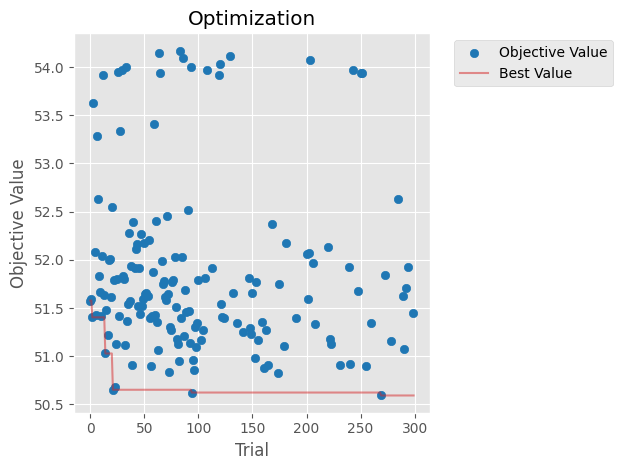

In [10]:
# >>> ────────────────────────────────────────────────────────────────────── <<<
# >>> CELL 10: OPTUNA STUDY                                                  <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Starting Optuna Study... using Device: {device}.')

# Set the level of logging
optuna.logging.set_verbosity(optuna.logging.INFO)

# Define the objective function (parameter space set here)
def objective(trial):
  hidden_channels = trial.suggest_categorical("hidden_channels", [320, 384, 448])
  lr = trial.suggest_float("lr", 3.2e-3, 4.6e-3, log=True)
  dropout = trial.suggest_float("dropout", 0.16, 0.18)
  weight_decay = trial.suggest_float("weight_decay", 4e-5, 6e-5, log=True)
  num_layers = trial.suggest_int("num_layers", 3, 4)
  aggr = trial.suggest_categorical("aggr", ["mean"])
  activation = trial.suggest_categorical("activation", ["relu"])
  batch_norm = trial.suggest_categorical("batch_norm", [False])
  residual = trial.suggest_categorical("residual", [True])
  accumulation_steps = trial.suggest_categorical("accumulation_steps", [10, 12])

  # Model and Optimizer definitions
  model = HeteroGraphModel(hidden_channels = hidden_channels, num_layers = num_layers,
                           dropout = dropout, aggr = aggr, activation = activation,
                           batch_norm = batch_norm, residual = residual).to(device)
  optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay = weight_decay)

  # Record the best metrics
  trial.set_user_attr("best_train_mse", float('inf'))
  trial.set_user_attr("best_train_rmse", float('inf'))
  trial.set_user_attr("best_train_r2", -float('inf'))
  trial.set_user_attr("best_val_mse", float('inf'))
  trial.set_user_attr("best_val_rmse", float('inf'))
  trial.set_user_attr("best_val_r2", -float('inf'))
  trial.set_user_attr("best_epoch", 0)

  # Save the best model weights
  os.makedirs('best_model_weights', exist_ok = True)
  best_model_path = f'best_model_weights/trial_{trial.number}_best_model_weight.pt'

  try:
    data_gpu = data.to(device)
  except:
    print('>>> Exception - messed it all up there when transferring data to the device <<<')

  # Set up the training loop
  best_val_rmse = float('inf')
  patience = patience_num
  patience_counter = 0
  # max_epochs = epoch_num
  for epoch in range(1, epoch_num + 1):         # Change max_epochs to epoch_num
      model.train()
      optimizer.zero_grad()
      loss_value = 0
      for step in range(accumulation_steps):
          out = model(data_gpu.x_dict, data_gpu.edge_index_dict)
          loss = F.mse_loss(out[data_gpu['county'].train_mask],
                            data_gpu['county'].y[data_gpu['county'].train_mask])
          loss = loss / accumulation_steps
          loss.backward()
          loss_value += loss.item()
      optimizer.step()
      train_loss = loss_value * accumulation_steps

      # Here is the evaluation step
      model.eval()
      with torch.no_grad():
        # Set preds
        pred = model(data_gpu.x_dict, data_gpu.edge_index_dict)

        # set the train vals
        train_pred = pred[data_gpu['county'].train_mask].cpu().numpy()
        train_true = data_gpu['county'].y[data_gpu['county'].train_mask].cpu().numpy()
        train_mse = mean_squared_error(train_true, train_pred)
        train_rmse = np.sqrt(train_mse)
        train_r2 = r2_score(train_true, train_pred)

        # set the evaluation vals
        val_pred = pred[data_gpu['county'].val_mask].cpu().numpy()
        val_true = data_gpu['county'].y[data_gpu['county'].val_mask].cpu().numpy()
        val_mse = mean_squared_error(val_true, val_pred)
        val_rmse = np.sqrt(val_mse)
        val_r2 = r2_score(val_true, val_pred)

        # report the vals
        trial.report(val_rmse, step=epoch)

        # PRUNING
        if trial.should_prune():
          raise optuna.exceptions.TrialPruned()

        # evaluate epoch against history
        if val_rmse < best_val_rmse:
          best_val_rmse = val_rmse
          patience_counter = 0

          # record best vals found
          trial.set_user_attr("best_train_mse", float(train_mse))
          trial.set_user_attr("best_train_rmse", float(train_rmse))
          trial.set_user_attr("best_train_r2", float(train_r2))
          trial.set_user_attr("best_val_mse", float(val_mse))
          trial.set_user_attr("best_val_rmse", float(val_rmse))
          trial.set_user_attr("best_val_r2", float(val_r2))
          trial.set_user_attr("best_epoch", epoch)

          # when best save weights
          torch.save(model.state_dict(), best_model_path)
        else:
          patience_counter += 1

        if patience_counter >= patience:
          print(f'\nWe hit the maximum patience at epoch: {epoch}')
          break

        # print the progress every 'n' epochs
        if epoch % 25 == 0 and trial.number < trial_num:
          print(f"Trial {trial.number}, Epoch {epoch}: val_rmse= {val_rmse:.2f}, val_R2= {val_r2:.2f}.")
  return best_val_rmse

# Set up the pruner
pruner = optuna.pruners.MedianPruner(n_startup_trials=100, n_warmup_steps=100,
                                     interval_steps=50)
# Set up the study
study = optuna.create_study(direction="minimize", study_name=study_name,
                            pruner=pruner)
n_trials = trial_num
# Run optimization
study.optimize(objective, n_trials=n_trials)

# Store trial data with best metrics
trial_records = []
for trial in study.trials:
    # Set parameters
    params = trial.params if trial.params else {}
    # Log best trials values
    trial_records.append({'trial_number': trial.number,
                          'timestamp': datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
                          'best_epoch': trial.user_attrs.get('best_epoch', 0),
                          'train_MSE': trial.user_attrs.get('best_train_mse', float('nan')),
                          'train_RMSE': trial.user_attrs.get('best_train_rmse', float('nan')),
                          'train_R2': trial.user_attrs.get('best_train_r2', float('nan')),
                          'validation_MSE': trial.user_attrs.get('best_val_mse', float('nan')),
                          'validation_RMSE': trial.user_attrs.get('best_val_rmse', float('nan')),
                          'validation_R2': trial.user_attrs.get('best_val_r2', float('nan')),
                          'hidden_channels': params.get('hidden_channels', None),
                          'lr': params.get('lr', None),
                          'dropout': params.get('dropout', None),
                          'weight_decay': params.get('weight_decay', None),
                          'num_layers': params.get('num_layers', None),
                          'aggr': params.get('aggr', None),
                          'activation': params.get('activation', None),
                          'batch_norm': params.get('batch_norm', None),
                          'residual': params.get('residual', None),
                          'accumulation_steps': params.get('accumulation_steps', None),
                          'state': str(trial.state)})
# Create a dataframe for the trial results
trials_df = pd.DataFrame(trial_records)

# Save the trial results
os.makedirs(optuna_results_directory, exist_ok=True)
trials_csv_path = os.path.join(optuna_results_directory, study_name + csv_part)
trials_df.to_csv(trials_csv_path, index=False)

print(f"\n----- Best trial -----")
print(f"  RMSE: {study.best_value:.4f}")
print(f"  Params: {study.best_params}")
print(f"  Best Epoch: {study.best_trial.user_attrs.get('best_epoch', 0)}")

# Plot the results of study
plot_path = os.path.join(optuna_results_directory, f"{study_name}_OptimizationPlot.png")
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.savefig(plot_path, dpi=600)
plt.title("Optimization")
plt.tight_layout()
plt.show()
# >>> END CELL 10                                                            <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<


>>> Training Final Model with Best Parameters <<<
Trianing final model using Best Parameters: {'hidden_channels': 320, 'lr': 0.003440590914208749, 'dropout': 0.17111205927810808, 'weight_decay': 4.9406183474048137e-05, 'num_layers': 3, 'aggr': 'mean', 'activation': 'relu', 'batch_norm': False, 'residual': True, 'accumulation_steps': 12}
Model initialized with dimensions: county=8, superfund=11, river=4
Epoch: 050, Train RMSE: 54.2279, Train R²: 0.1285, Val RMSE: 55.4532, Val R²: 0.0970
Epoch: 100, Train RMSE: 52.1621, Train R²: 0.1936, Val RMSE: 54.2176, Val R²: 0.1367
Epoch: 150, Train RMSE: 51.3414, Train R²: 0.2188, Val RMSE: 53.8719, Val R²: 0.1477
Epoch: 200, Train RMSE: 50.5458, Train R²: 0.2428, Val RMSE: 53.5548, Val R²: 0.1577
Epoch: 250, Train RMSE: 49.5606, Train R²: 0.2720, Val RMSE: 53.0230, Val R²: 0.1744
Epoch: 300, Train RMSE: 48.8497, Train R²: 0.2928, Val RMSE: 52.5934, Val R²: 0.1877
Epoch: 350, Train RMSE: 47.9380, Train R²: 0.3189, Val RMSE: 51.9870, Val R²: 0.206

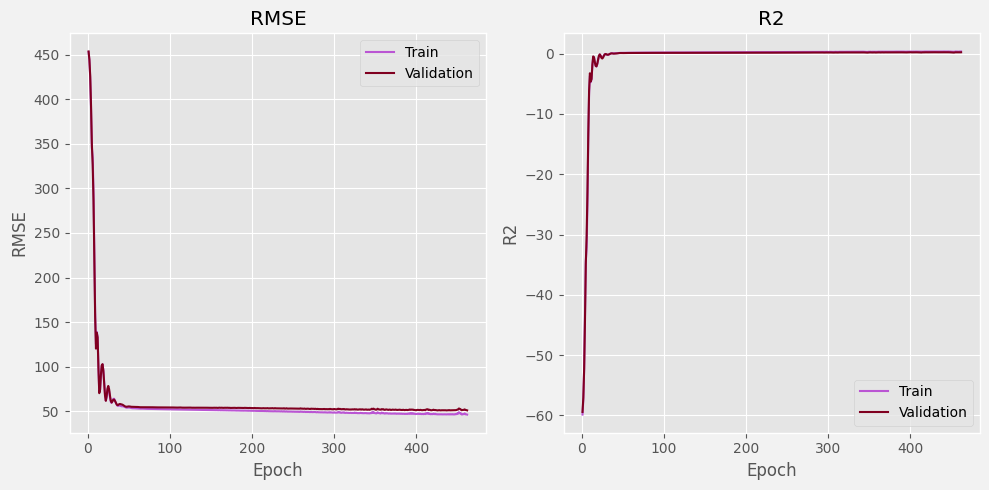

Model weights saved to: final_model_results/May5_Test__FinalModelEval_v1__model_weights.pt
Final model complete. Great success!
>>> ──────────────────────────────────── <<<


In [11]:
# >>> ────────────────────────────────────────────────────────────────────── <<<
# >>> CELL 11: TRAIN, EVALUATE, LOG A FINAL MODEL WIHT BEST PARAMETERS       <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<

# FUNCTION: Train final model
def train_final_model(params, epochs=epoch_num, patience=patience_num):
    # use the best parameters
    model = HeteroGraphModel(hidden_channels=params['hidden_channels'], num_layers=params['num_layers'],
                             dropout=params['dropout'], aggr=params['aggr'], activation=params['activation'],
                             batch_norm=params['batch_norm'], residual=params['residual']).to(device)
    # optimizer - starting
    optimizer = optim.Adam(model.parameters(), lr=params['lr'], weight_decay=params['weight_decay'])

    data_gpu = data.to(device)
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

    # the training loop
    best_val_rmse = float('inf')
    best_model_state = None
    patience_counter = 0

    # tracking
    train_losses = []
    val_rmses = []
    val_r2s = []

    # record list
    training_records = []

    # training loop
    for epoch in range(1, (epochs * 2) + 1):
        model.train()
        optimizer.zero_grad()
        # Use gradient accumulation if specified
        accumulation_steps = params.get('accumulation_steps', 1)
        loss_value = 0
        for step in range(accumulation_steps):
            out = model(data_gpu.x_dict, data_gpu.edge_index_dict)
            loss = F.mse_loss(
                out[data_gpu['county'].train_mask],
                data_gpu['county'].y[data_gpu['county'].train_mask]
            )
            # Scale the loss to account for accumulation
            loss = loss / accumulation_steps
            loss.backward()
            loss_value += loss.item()
        optimizer.step()
        train_loss = loss_value * accumulation_steps
        train_losses.append(train_loss)
        # Evaluation step
        model.eval()
        with torch.no_grad():
            pred = model(data_gpu.x_dict, data_gpu.edge_index_dict)
            # Training metrics
            train_pred = pred[data_gpu['county'].train_mask].cpu().numpy()
            train_true = data_gpu['county'].y[data_gpu['county'].train_mask].cpu().numpy()
            train_mse = mean_squared_error(train_true, train_pred)
            train_rmse = np.sqrt(train_mse)
            train_r2 = r2_score(train_true, train_pred)
            # Validation metrics
            val_pred = pred[data_gpu['county'].val_mask].cpu().numpy()
            val_true = data_gpu['county'].y[data_gpu['county'].val_mask].cpu().numpy()
            val_mse = mean_squared_error(val_true, val_pred)
            val_rmse = np.sqrt(val_mse)
            val_r2 = r2_score(val_true, val_pred)
            val_rmses.append(val_rmse)
            val_r2s.append(val_r2)

        is_best = val_rmse < best_val_rmse
        training_records.append({
            'epoch': epoch,
            'train_MSE': train_mse,
            'train_RMSE': train_rmse,
            'train_R2': train_r2,
            'validation_MSE': val_mse,
            'validation_RMSE': val_rmse,
            'validation_R2': val_r2,
            'best_so_far': is_best
        })
        # Progression
        if epoch % 50 == 0:
            print(f"Epoch: {epoch:03d}, Train RMSE: {train_rmse:.4f}, Train R²: {train_r2:.4f}, Val RMSE: {val_rmse:.4f}, Val R²: {val_r2:.4f}")
        # Early stopper
        if is_best:
            best_val_rmse = val_rmse
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    # Create training log dataframe
    training_log = pd.DataFrame(training_records)
    # Save training log to CSV
    os.makedirs(final_model_results_directory, exist_ok=True)
    log_path = os.path.join(final_model_results_directory, model_name + csv_part)
    training_log.to_csv(log_path, index=False)
    print(f"Training log saved to: {log_path}")
    sort_train = training_log.sort_values(by='validation_RMSE')
    print('---------------------------------------')
    print('------ Best by [validation_RMSE] ------')
    print('---------------------------------------')
    print(sort_train.head(5))

    # Save model parameters
    param_des = f'__ModelParams__'
    params_path = os.path.join(final_model_results_directory, model_name + param_des + json_part)
    with open(params_path, 'w') as f:
        import json
        json.dump({k: str(v) if isinstance(v, (type, torch.device)) else v
                   for k, v in params.items()}, f, indent=2)
    print(f"Model parameters saved to: {params_path}")

    # Load best model
    model.load_state_dict(best_model_state)

    # Final evaluation
    model.eval()
    with torch.no_grad():
        pred = model(data_gpu.x_dict, data_gpu.edge_index_dict)

        # Training metrics
        train_pred = pred[data_gpu['county'].train_mask].cpu().numpy()
        train_true = data_gpu['county'].y[data_gpu['county'].train_mask].cpu().numpy()
        train_mse = mean_squared_error(train_true, train_pred)
        train_rmse = np.sqrt(train_mse)
        train_r2 = r2_score(train_true, train_pred)

        # Validation metrics
        val_pred = pred[data_gpu['county'].val_mask].cpu().numpy()
        val_true = data_gpu['county'].y[data_gpu['county'].val_mask].cpu().numpy()
        val_mse = mean_squared_error(val_true, val_pred)
        val_rmse = np.sqrt(val_mse)
        val_r2 = r2_score(val_true, val_pred)

    # Save the final results
    final_results = {
                     'timestamp': timestamp,
                     'train_mse': float(train_mse),
                     'train_rmse': float(train_rmse),
                     'train_r2': float(train_r2),
                     'val_mse': float(val_mse),
                     'val_rmse': float(val_rmse),
                     'val_r2': float(val_r2),
                     'epochs_trained': len(train_losses),
                     'early_stopped': patience_counter >= patience,
                     'parameters': {k: str(v) if isinstance(v, (type, torch.device)) else v
                                    for k, v in params.items()}
                     }
    fin_res = f'__FinalResults__'
    results_path = os.path.join(final_model_results_directory, model_name + fin_res + json_part)
    with open(results_path, 'w') as f:
        import json
        json.dump(final_results, f, indent=2)

    # start_epoch = 50

    # Plot the training history
    # facecolor = '#f2f2f2', primary data series = '#800020', secondary data series = '#BA55D3'
    plt.figure(figsize=(10, 5), facecolor='#f2f2f2')
    plt.subplot(1, 2, 1)
    plt.plot(training_log['epoch'], training_log['train_RMSE'], label='Train', color='#BA55D3')
    plt.plot(training_log['epoch'], training_log['validation_RMSE'], label='Validation', color='#800020')
    plt.title('RMSE')
    plt.xlabel('Epoch')
    plt.ylabel('RMSE')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(training_log['epoch'], training_log['train_R2'], label='Train', color='#BA55D3')
    plt.plot(training_log['epoch'], training_log['validation_R2'], label='Validation', color='#800020')
    plt.title('R2')
    plt.xlabel('Epoch')
    plt.ylabel('R2')
    plt.legend()

    # Save the plot
    curve_pl = '__LearningCurve__'
    plot_path = os.path.join(final_model_results_directory, model_name + curve_pl + png_part)
    plt.tight_layout()
    plt.savefig(plot_path)
    plt.show()

    # Save model weights
    model_path = os.path.join(final_model_results_directory, model_name + f'__model_weights.pt')
    torch.save(model.state_dict(), model_path)
    print(f"Model weights saved to: {model_path}")

    # return the model but also the train/val rmse and r2
    return model, train_rmse, val_rmse, train_r2, val_r2

try:
  print('\n>>> Training Final Model with Best Parameters <<<')
  print(f'Trianing final model using Best Parameters: {study.best_params}')
  final_model, train_rmse, val_rmse, train_r2, val_r2 = train_final_model(study.best_params)
  print('Final model complete. Great success!')
  print('>>> ──────────────────────────────────── <<<')
except:
  print('\nNope, borked on final model. Revise, try again.')
# >>> END CELL 11                                                            <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<


=== Model Component Importance Analysis ===
Base RMSE (all components): 51.0235

--- River Feature Importance ---
Impact of removing river scalerank_norm: RMSE diff = 28.2505
Impact of removing river scalerank_norm: RMSE diff = 28.2505
Impact of removing river length_km_norm: RMSE diff = 51.1847
Impact of removing river length_km_norm: RMSE diff = 51.1847
Impact of removing river basin_km2_norm: RMSE diff = 74.4054
Impact of removing river basin_km2_norm: RMSE diff = 74.4054
Impact of removing river discharge_norm: RMSE diff = 68.6504
Impact of removing river discharge_norm: RMSE diff = 68.6504

--- County Feature Importance ---
Impact of removing avg_annual_count: RMSE diff = 28.2505
Impact of removing five_year_trend: RMSE diff = 51.1847
Impact of removing rural_rural: RMSE diff = 74.4054
Impact of removing rural_urban: RMSE diff = 68.6504
Impact of removing trend_: RMSE diff = 41.7162
Impact of removing trend_falling: RMSE diff = 32.0147
Impact of removing trend_rising: RMSE diff =

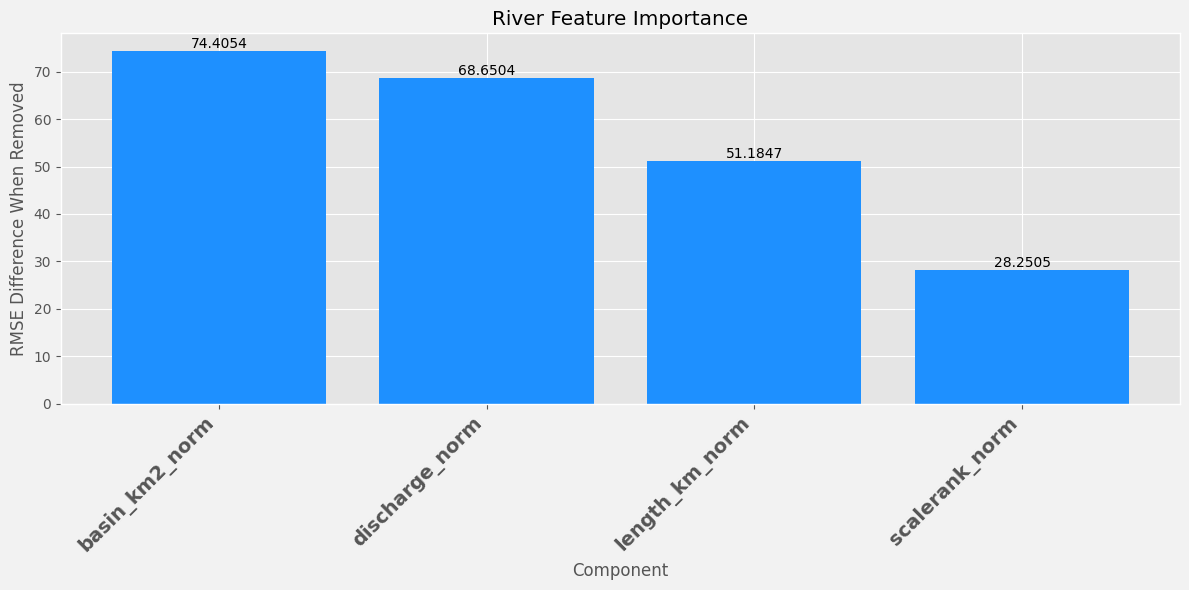

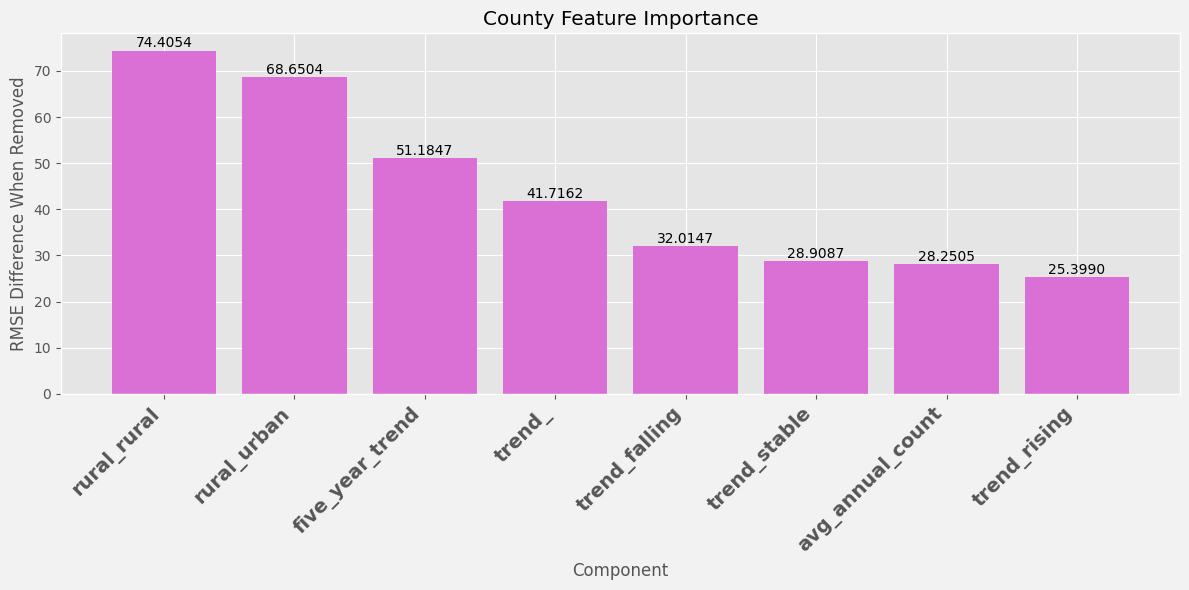

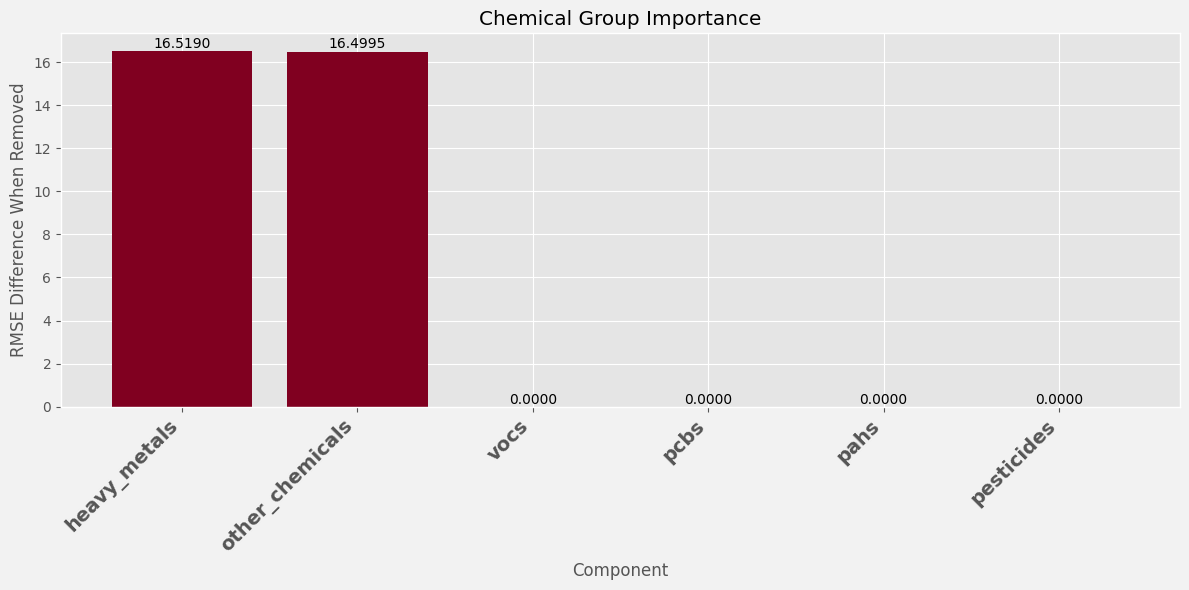

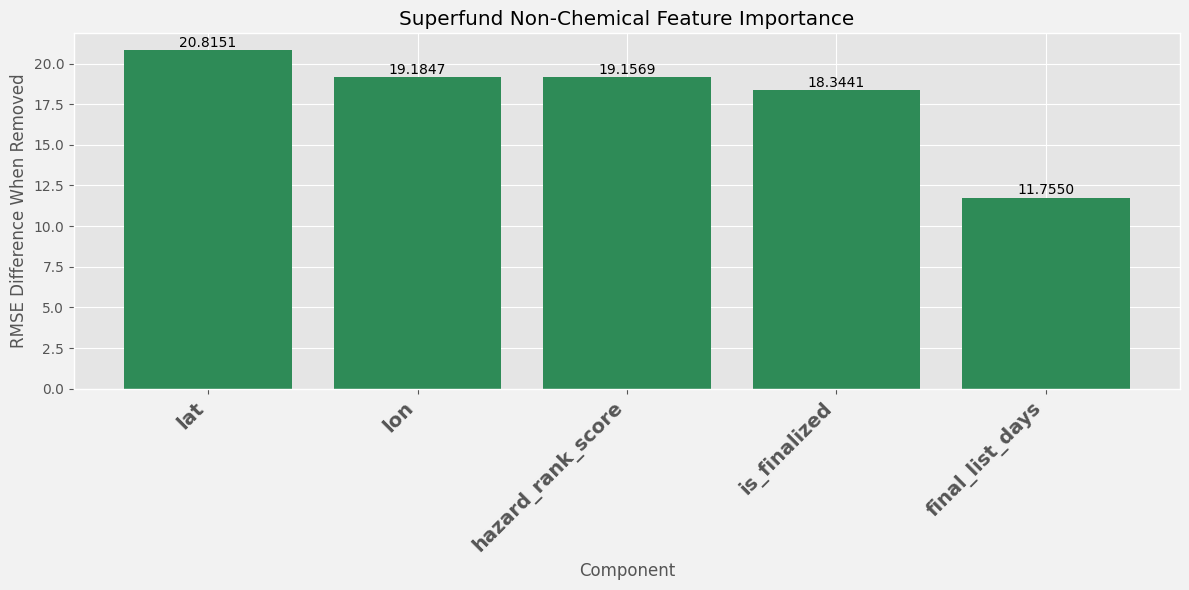

In [12]:
# >>> ────────────────────────────────────────────────────────────────────── <<<
# >>> CELL 12: DOING A.UH ABLATION TEST ON TEH FEATURES TO TEST IMPORTANCE   <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<

def analyze_model_importance(model, data_gpu, results_dir='model_results'):
    print("\n=== Model Component Importance Analysis ===")
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    os.makedirs(results_dir, exist_ok=True)

    # Base performance with all components intact
    model.eval()
    with torch.no_grad():
        base_out = model(data_gpu.x_dict, data_gpu.edge_index_dict)
        base_loss = F.mse_loss(
            base_out[data_gpu['county'].val_mask],
            data_gpu['county'].y[data_gpu['county'].val_mask]
        )
        base_rmse = torch.sqrt(base_loss).item()
        base_pred = base_out[data_gpu['county'].val_mask].cpu().numpy()

    print(f"Base RMSE (all components): {base_rmse:.4f}")

    # Helper function to compute importance by zeroing out features
    def compute_importance(node_type=None, feature_idx=None, feature_name=None,
                          chemical_group=None, non_chemical_features=None):
        try:
            # Create modified features dictionary
            modified_x_dict = {k: v.clone() for k, v in data_gpu.x_dict.items()}

            if node_type:
                # Zero out entire node type
                modified_x_dict[node_type] = torch.zeros_like(modified_x_dict[node_type])
                display_name = f"Without {node_type.capitalize()}s"
            elif feature_idx is not None and feature_name:
                # Zero out specific county feature
                modified_x_dict['county'][:, feature_idx] = 0
                display_name = feature_name
            elif chemical_group:
                # Zero out chemical group (requires original feature grouping)
                if 'superfund_grouped_features' not in globals():
                    return None, f"Cannot analyze {chemical_group} - original features not available"

                # Create modified superfund features
                modified_features = superfund_grouped_features.copy()
                modified_features[chemical_group] = 0

                # Apply transformation
                scaler = StandardScaler()
                modified_scaled = scaler.fit_transform(modified_features)

                pca = PCA(n_components=data_gpu['superfund'].x.shape[1])
                modified_reduced = pca.fit_transform(modified_scaled)

                modified_x_dict['superfund'] = torch.tensor(
                    modified_reduced, dtype=torch.float32
                ).to(data_gpu['superfund'].x.device)

                display_name = chemical_group
            elif non_chemical_features:
                # Zero out non-chemical superfund features
                if 'superfund_grouped_features' not in globals():
                    return None, f"Cannot analyze {non_chemical_features} - original features not available"

                # Create modified superfund features
                modified_features = superfund_grouped_features.copy()
                # These are non-chemical features (e.g., location, size, age)
                modified_features[non_chemical_features] = 0

                # Apply transformation
                scaler = StandardScaler()
                modified_scaled = scaler.fit_transform(modified_features)

                pca = PCA(n_components=data_gpu['superfund'].x.shape[1])
                modified_reduced = pca.fit_transform(modified_scaled)

                modified_x_dict['superfund'] = torch.tensor(
                    modified_reduced, dtype=torch.float32
                ).to(data_gpu['superfund'].x.device)

                display_name = non_chemical_features

            # Compute modified predictions
            with torch.no_grad():
                modified_out = model(modified_x_dict, data_gpu.edge_index_dict)
                modified_pred = modified_out[data_gpu['county'].val_mask].cpu().numpy()

            # Calculate impact
            if feature_idx is not None or chemical_group or non_chemical_features:
                # For feature importance, use difference in predictions
                mse_diff = mean_squared_error(base_pred, modified_pred)
                importance = np.sqrt(mse_diff)
            else:
                # For node type importance, use RMSE on target values
                modified_loss = F.mse_loss(
                    modified_out[data_gpu['county'].val_mask],
                    data_gpu['county'].y[data_gpu['county'].val_mask]
                )
                modified_rmse = torch.sqrt(modified_loss).item()
                importance = modified_rmse - base_rmse

            return importance, display_name
        except Exception as e:
            return None, f"Error: {str(e)}"

    # Do the river feature importances
    river_feature_importance = {}
    print("\n--- River Feature Importance ---")
    river_feature_names = river_features.columns.tolist()
    for i, feature in enumerate(river_feature_names):
      # Create modified features with this feature zeroed out
      importance, _ = compute_importance(feature_idx=i, feature_name=feature)
      river_feature_importance[feature] = importance
      print(f"Impact of removing river {feature}: RMSE diff = {importance:.4f}")
      # modified_x_dict = {k: v.clone() for k, v in data_gpu.x_dict.items()}
      # modified_x_dict['river'][:, i] = 0
      # # Get predictions
      # with torch.no_grad():
      #     modified_out = model(modified_x_dict, data_gpu.edge_index_dict)
      #     modified_pred = modified_out[data_gpu['county'].val_mask].cpu().numpy()
      # # Calculate impact
      # mse_diff = mean_squared_error(base_pred, modified_pred)
      # importance = np.sqrt(mse_diff)
      # river_feature_importance[feature] = importance
      print(f"Impact of removing river {feature}: RMSE diff = {importance:.4f}")

    # 3. do the county feature importance
    county_importance = {}
    print("\n--- County Feature Importance ---")
    feature_names = county_features.columns.tolist()
    for i, feature in enumerate(feature_names):
        importance, _ = compute_importance(feature_idx=i, feature_name=feature)
        county_importance[feature] = importance
        print(f"Impact of removing {feature}: RMSE diff = {importance:.4f}")

    # Do the chemical group importance
    chemical_importance = {}
    print("\n--- Chemical Group Importance ---")
    chemical_groups = [col for col in superfund_grouped_features.columns
                      if col in ['heavy_metals', 'vocs', 'pahs', 'pcbs', 'pesticides', 'other_chemicals']]
    for group in chemical_groups:
        importance, _ = compute_importance(chemical_group=group)
        chemical_importance[group] = importance
        print(f"Impact of removing {group}: RMSE diff = {importance:.4f}")

    # Do the Superfund Non-Chemical Feature Importances
    non_chemical_importance = {}
    print("\n--- Superfund Non-Chemical Feature Importance ---")
    # non-chemical features are all superfund columns not in chemical_groups
    chemical_groups = ['heavy_metals', 'vocs', 'pahs', 'pcbs', 'pesticides', 'other_chemicals']
    non_chemical_groups = [col for col in superfund_grouped_features.columns if col not in chemical_groups]
    for feature in non_chemical_groups:
        importance, _ = compute_importance(non_chemical_features=feature)
        non_chemical_importance[feature] = importance
        print(f"Impact of removing {feature}: RMSE diff = {importance:.4f}")

    # plot the importances
    def plot_importance(importance_dict, title, filename_prefix, color='#800020'):
        plt.figure(figsize=(12, 6), facecolor = '#f2f2f2')
        labels = list(importance_dict.keys())
        values = list(importance_dict.values())
        # sort by the importance
        sorted_indices = np.argsort(values)[::-1]
        labels = [labels[i] for i in sorted_indices]
        values = [values[i] for i in sorted_indices]
        bars = plt.bar(labels, values, color=color)
        plt.title(title)
        plt.xlabel('Component')
        plt.ylabel('RMSE Difference When Removed')
        plt.xticks(rotation=45, ha='right', fontsize=14, fontweight='bold')

        # label the values
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.005, f'{height:.4f}',
                     ha='center', va='bottom')
        plt.tight_layout()
        plot_path = os.path.join(results_dir, f"{filename_prefix}_{timestamp}.png")
        plt.savefig(plot_path)
        plt.show()

        # Save to CSV
        results_df = pd.DataFrame({'component': labels, 'importance_score': values})
        results_df.to_csv('feature_importance.csv')

    # Plot results for the feature sets
    # facecolor = '#f2f2f2'
    # superfund_chemical group = '#800020', county group = '#BA55D3'
    # superfund_non-chemical group = '#2E8B57', county group = '#1E90FF'
    plot_importance(river_feature_importance, 'River Feature Importance', 'river_feature_importance', color='#1E90FF')
    plot_importance(county_importance, 'County Feature Importance', 'county_feature_importance', color='#DA70D6')
    plot_importance(chemical_importance, 'Chemical Group Importance', 'chemical_importance', color='#800020')
    plot_importance(non_chemical_importance, 'Superfund Non-Chemical Feature Importance',
                    'superfund_non_chemical_importance', color='#2E8B57')

    return {'river_feature_importance': river_feature_importance,
            'county_importance': county_importance,
            'chemical_importance': chemical_importance,
            'non_chemical_importance': non_chemical_importance}

# Run the analysis
data_gpu = data.to(device)
importance_results = analyze_model_importance(final_model, data_gpu)

# >>> END CELL 12                                                            <<<
# >>> ────────────────────────────────────────────────────────────────────── <<<